## Dataset

In [ ]:
from huggingface_hub import login

login()

c:\Users\Marcin\Desktop\ZPRP\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from datasets import load_dataset
battlemaps_dataset = load_dataset("Rpgshit/battlemaps-description-generated")

In [ ]:
battlemaps_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 3965
    })
    validation: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 496
    })
    test: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 496
    })
})

# CLIP

In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModel

In [ ]:
Image.MAX_IMAGE_PIXELS = None

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    dtype=torch.float32,
    attn_implementation="sdpa"
).to(device)

processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [ ]:
from torch.utils.data import DataLoader
from random import choice

def collate_fn(batch):
    images = [item['image'] for item in batch]
    texts = [choice([item['description'], item['short_description']]) for item in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    )
    return inputs

BATCH_SIZE = 32
test_loader = DataLoader(
    battlemaps_dataset['test'],
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn
)

In [ ]:
import torch
import torch.nn.functional as F
import torchmetrics
from tqdm import tqdm

loss_metric = torchmetrics.aggregation.MeanMetric().to(device)
img_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)
cap_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)

model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text

        batch_size = logits_per_image.size(0)
        labels = torch.arange(batch_size, device=device)

        loss_i = F.cross_entropy(logits_per_image, labels)
        loss_t = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i + loss_t) / 2

        img_preds = logits_per_image.argmax(dim=1)
        img_acc = (img_preds == labels).float().mean()

        txt_preds = logits_per_text.argmax(dim=1)
        cap_acc = (txt_preds == labels).float().mean()

        loss_metric.update(loss)
        img_acc_metric.update(img_acc)
        cap_acc_metric.update(cap_acc)

final_loss = loss_metric.compute()
final_img_acc = img_acc_metric.compute()
final_cap_acc = cap_acc_metric.compute()

print("\n" + "="*40)
print(f"Loss: {final_loss:.4f}")
print(f"Image Retrieval Accuracy (Img->Txt): {final_img_acc:.2%}")
print(f"Caption Retrieval Accuracy (Txt->Img): {final_cap_acc:.2%}")
print("="*40)

loss_metric.reset()
img_acc_metric.reset()
cap_acc_metric.reset()

Rozpoczynam ewaluację (Hugging Face CLIP)...


100%|██████████| 16/16 [01:11<00:00,  4.50s/it]


Loss: 2.6953
Image Retrieval Accuracy (Img->Txt): 33.01%
Caption Retrieval Accuracy (Txt->Img): 40.82%


In [ ]:
train_loader = DataLoader(battlemaps_dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [ ]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm

EPOCHS = 3
LEARNING_RATE = 5e-6
WEIGHT_DECAY = 0.2

model.train()

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

for epoch in range(EPOCHS):
    total_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{EPOCHS}")

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text

        current_batch_size = logits_per_image.size(0)
        labels = torch.arange(current_batch_size, device=device)

        loss_i = F.cross_entropy(logits_per_image, labels)
        loss_t = F.cross_entropy(logits_per_text, labels)

        loss = (loss_i + loss_t) / 2

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(train_loader)
    print(f"Koniec epoki {epoch+1}, Średnia strata: {avg_loss:.4f}")

# Zapisanie modelu
model.save_pretrained("./douczony-clip")
processor.save_pretrained("./douczony-clip")

Epoka 1/3:  67%|██████▋   | 83/124 [08:03<05:45,  8.43s/it, loss=1.23] c:\Users\Marcin\Desktop\ZPRP\env\lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoka 1/3: 100%|██████████| 124/124 [13:49<00:00,  6.69s/it, loss=1.38] 


Koniec epoki 1, Średnia strata: 1.3884


Epoka 2/3: 100%|██████████| 124/124 [16:35<00:00,  8.03s/it, loss=0.908]


Koniec epoki 2, Średnia strata: 0.8228


Epoka 3/3: 100%|██████████| 124/124 [16:22<00:00,  7.92s/it, loss=0.824]


Koniec epoki 3, Średnia strata: 0.5423


[]

In [ ]:
loss_metric = torchmetrics.aggregation.MeanMetric().to(device)
img_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)
cap_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)

model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text

        batch_size = logits_per_image.size(0)
        labels = torch.arange(batch_size, device=device)

        loss_i = F.cross_entropy(logits_per_image, labels)
        loss_t = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i + loss_t) / 2

        img_preds = logits_per_image.argmax(dim=1)
        img_acc = (img_preds == labels).float().mean()

        txt_preds = logits_per_text.argmax(dim=1)
        cap_acc = (txt_preds == labels).float().mean()

        loss_metric.update(loss)
        img_acc_metric.update(img_acc)
        cap_acc_metric.update(cap_acc)

final_loss = loss_metric.compute()
final_img_acc = img_acc_metric.compute()
final_cap_acc = cap_acc_metric.compute()

print("\n" + "="*40)
print(f"Loss: {final_loss:.4f}")
print(f"Image Retrieval Accuracy (Img->Txt): {final_img_acc:.2%}")
print(f"Caption Retrieval Accuracy (Txt->Img): {final_cap_acc:.2%}")
print("="*40)

loss_metric.reset()
img_acc_metric.reset()
cap_acc_metric.reset()

100%|██████████| 16/16 [02:00<00:00,  7.53s/it]


Loss: 1.1513
Image Retrieval Accuracy (Img->Txt): 68.16%
Caption Retrieval Accuracy (Txt->Img): 68.55%


In [ ]:
from torch.utils.data import DataLoader

def collate_fn2(batch):
    images = [item['image'] for item in batch]

    inputs = processor(
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    )
    return inputs

BATCH_SIZE = 32
image_loader = DataLoader(
    battlemaps_dataset['test'],
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn2
)

In [ ]:

model.eval()

def get_image_embeddings(loader):
    all_embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            image_features = model.get_image_features(pixel_values=batch["pixel_values"])
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            all_embeddings.append(image_features.cpu())

    return torch.cat(all_embeddings)


image_index = get_image_embeddings(image_loader)
print(f"Zindeksowano {image_index.shape[0]} obrazów. Wymiar wektora: {image_index.shape[1]}")


Zindeksowano 496 obrazów. Wymiar wektora: 512


In [ ]:
battlemaps_dataset['test'][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 'short_description': 'Palace Courtyard',
 'description': 'dungeon interior trees'}

In [ ]:
def search_images(query_text, k=3):
    with torch.no_grad():
        inputs = processor(text=[query_text], return_tensors="pt", padding=True).to(device)
        text_features = model.get_text_features(**inputs)

        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        similarities = (text_features @ image_index.T.to(device)).squeeze(0)

        values, indices = similarities.topk(k)

    return values.cpu().numpy(), indices.cpu().numpy()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_searh_images(zapytanie, k=3):
    scores, indices = search_images(zapytanie, k=k)

    print(f"\nWyniki dla zapytania: '{zapytanie}'")

    fig, axes = plt.subplots(1, k, figsize=(15, 5))
    if not isinstance(axes, (list, np.ndarray)): axes = [axes]

    for i, (score, idx) in enumerate(zip(scores, indices)):
        img = battlemaps_dataset['test'][int(idx)]['image']
        true_desc = battlemaps_dataset['test'][int(idx)]['short_description']

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Score: {score:.4f}\nTrue: {true_desc[:30]}...")

    plt.show()


Wyniki dla zapytania: 'Palace Courtyard'


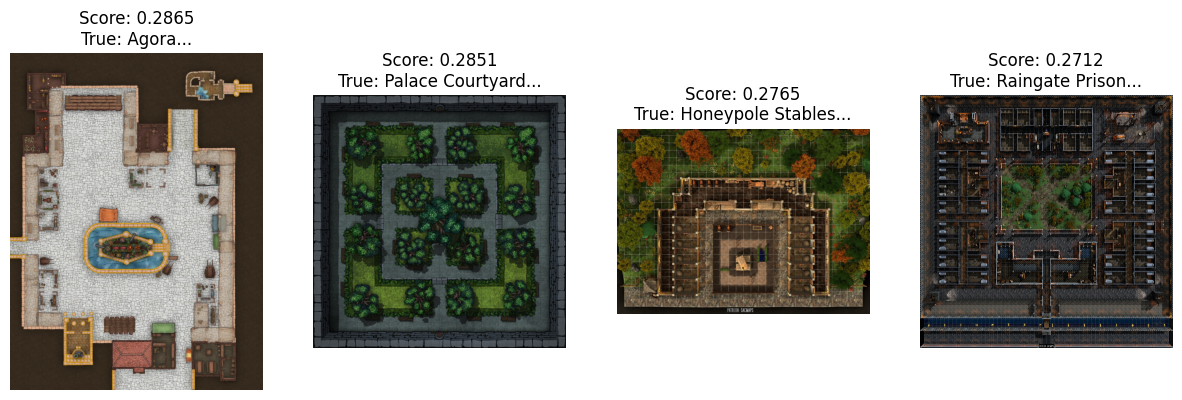

In [ ]:
zapytanie = "Palace Courtyard"
draw_searh_images(zapytanie, k=4)


Wyniki dla zapytania: 'Dark cave with threasure'


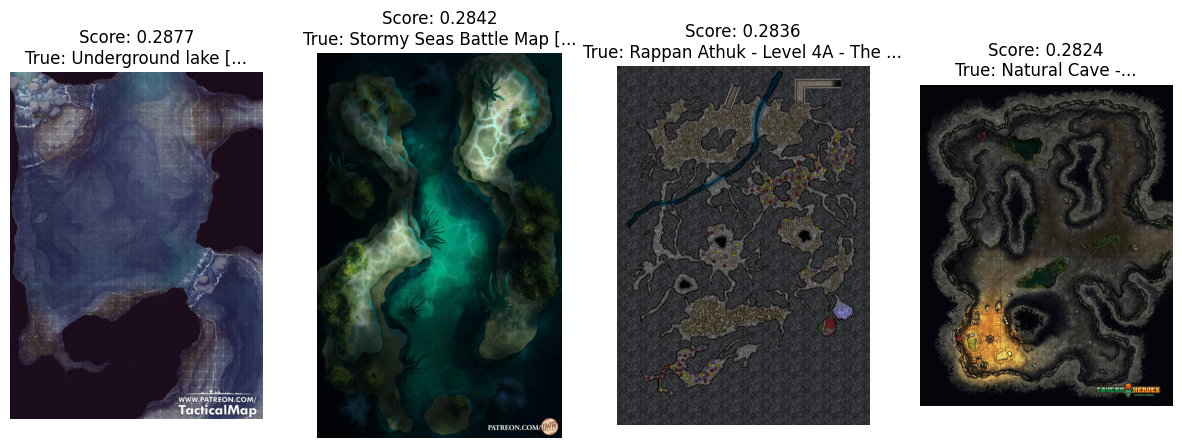

In [ ]:
zapytanie ="Dark cave with threasure"
draw_searh_images(zapytanie, k=4)


Wyniki dla zapytania: 'Big castle'


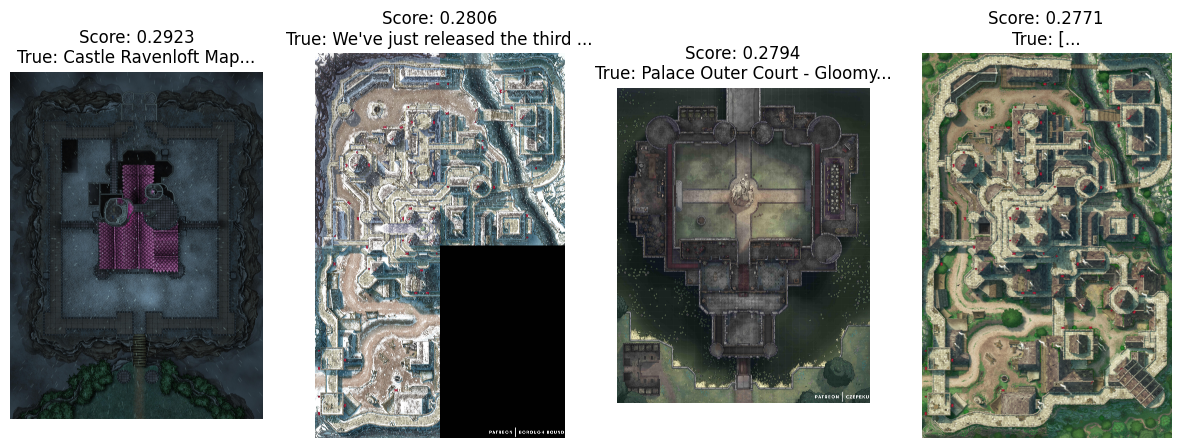

In [ ]:
zapytanie = "Big castle"
draw_searh_images(zapytanie, k=4)


Wyniki dla zapytania: 'Forest, path, stones, river'


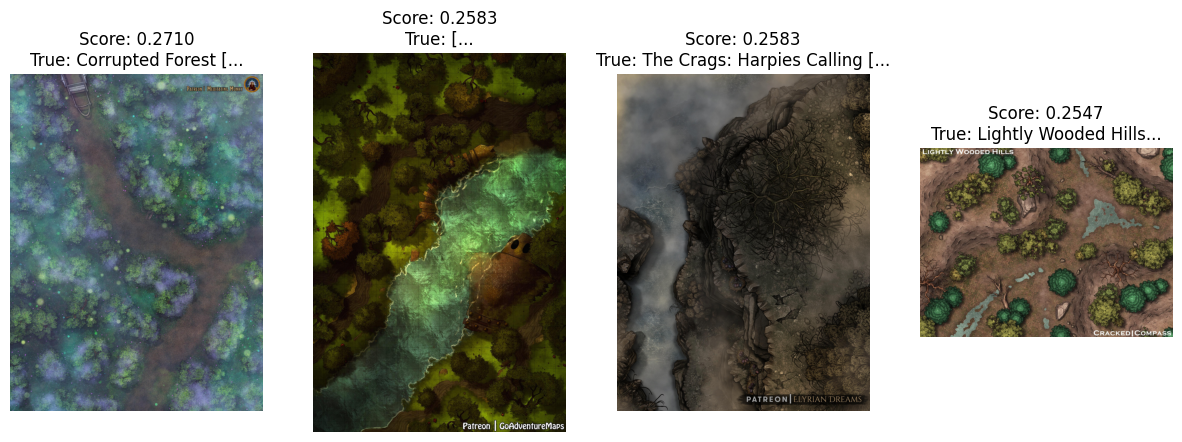

In [ ]:
zapytanie = "Forest, path, stones, river"
draw_searh_images(zapytanie, k=4)